In [1]:
#Libraries constants and utilities
#Libraries
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import seaborn as sns
from pathlib import Path
from scipy import stats

#Constants
DATA = Path("../data")
FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)

#Mood quadrant colors used consistently across all plots
MOOD_COLORS = {
    "Joyful/Energetic": "#F4A261",
    "Content/Peaceful": "#2A9D8F",
    "Tense/Angry": "#E76F51",
    "Sad/Melancholic": "#457B9D",
}

#Thayer thresholds
V_THRESHOLD = 0.5
E_THRESHOLD = 0.5

#Visual settings for metplotlib and seaborn plots
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
sns.set_style("whitegrid")

#Utilities
import sys
sys.path.append('../utilities')
from utils import categorize_mood

# Disclaimer - after multiple RAM issues on local machine in this notebook it was refactored to be loading only the needed ccolumns and compact dtypes will be used

# 3. EDA & Mood Distribution
This notebook explores all three cleaned datasets visually before any formal statistical testing. Its purpose is to establish whether the data contains the kind of signal that the three project experiments are designed to detect.

The analytical framework used throughout is **Thayer's two-dimensional model of mood** (valence x energy), introduced in notebook `01-data profiling.ipynb`. Audio features from DS2 are used to position each charting track within that space.

In [3]:
#DS2 loading only needed columns float32 halves audio feature memory vs default float64;
DS2_COLS = [
    "spotify_id", "country", "snapshot_date", "year", "month",
    "valence", "energy", "danceability", "loudness",
    "tempo", "acousticness", "instrumentalness", "speechiness", "liveness"
]
DS2_DTYPES = {
    "spotify_id": "category",
    "country": "category",
    "year": "int16",
    "month": "int8",
    "valence": "float32",
    "energy": "float32",
    "danceability": "float32",
    "loudness": "float32",
    "tempo": "float32",
    "acousticness": "float32",
    "instrumentalness": "float32",
    "speechiness": "float32",
    "liveness": "float32",
}

ds2 = pd.read_csv(
    DATA / "ds2_cleaned.csv",
    usecols=DS2_COLS,
    dtype=DS2_DTYPES,
    parse_dates=["snapshot_date"]
)
ds3 = pd.read_csv(DATA / "ds3_cleaned.csv")
ds4 = pd.read_csv(DATA / "ds4_cleaned.csv")

ds2_mb = ds2.memory_usage(deep=True).sum() / 1024**2
print(f"DS2: {len(ds2):,} rows, {ds2_mb:.0f} MB in memory | DS3: {len(ds3):,} rows | DS4: {len(ds4):,} rows")

DS2: 2,081,408 rows, 101 MB in memory | DS3: 736 rows | DS4: 143 rows


In [5]:
#Mapping regional label to DS2 from DS4
region_lookup = (
    ds4[["country_code", "Regional indicator"]]
    .dropna(subset=["country_code"])
    .rename(columns={"country_code": "country", "Regional indicator": "region"})
)

# category dtype on 'country' in ds2 requires add_categories before merge
ds2["country"] = ds2["country"].cat.add_categories(
    [c for c in region_lookup["country"] if c not in ds2["country"].cat.categories]
)
ds2 = ds2.merge(region_lookup, on="country", how="left")
ds2["region"] = ds2["region"].astype("category")

matched = ds2["region"].notna().sum()
print(f"DS2 rows with region assigned: {matched:,} of {len(ds2):,} ({matched / len(ds2) * 100:.1f}%)")
print(f"Unique regions: {sorted(ds2['region'].dropna().unique())}")

DS2 rows with region assigned: 1,994,031 of 2,081,408 (95.8%)
Unique regions: ['Central and Eastern Europe', 'Commonwealth of Independent States', 'East Asia', 'Latin America and Caribbean', 'Middle East and North Africa', 'North America and ANZ', 'South Asia', 'Southeast Asia', 'Sub-Saharan Africa', 'Western Europe']


In [6]:
print(ds2.columns.to_list())

['spotify_id', 'country', 'snapshot_date', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'year', 'month', 'region']


### Mood Distribution Overview
Before looking at geography or time, the first question is: **Where does all charting music sit in Thayer's two-dimensional mood space?**

The plot below uses a hexagonal binning approach instead of a raw scatter plot. To ensure more accurate results, only unique songs are included rather than all rows where tracks may be repeated. This method divides the scatter plot space into a grid of hexagons and colours each one according to the number of tracks it contains, making patterns of density much easier to interpret.

In [30]:
ds2_unique = ds2.drop_duplicates(subset="spotify_id").copy()
conditions = [
    (ds2_unique["valence"] >= V_THRESHOLD) & (ds2_unique["energy"] >= E_THRESHOLD),
    (ds2_unique["valence"] >= V_THRESHOLD) & (ds2_unique["energy"] <  E_THRESHOLD),
    (ds2_unique["valence"] <  V_THRESHOLD) & (ds2_unique["energy"] >= E_THRESHOLD),
    (ds2_unique["valence"] <  V_THRESHOLD) & (ds2_unique["energy"] <  E_THRESHOLD),
]
choices = ["Joyful/Energetic", "Content/Peaceful", "Tense/Angry", "Sad/Melancholic"]
ds2_unique["mood"] = pd.Categorical(
    np.select(conditions, choices, default="Unknown"),
    categories=choices
)

mood_dist = (
    ds2_unique["mood"].value_counts()
    .rename_axis("Mood Category")
    .reset_index(name="Count")
)
mood_dist["Percentage"] = (mood_dist["Count"] / len(ds2_unique) * 100).round(1)
print(f"Mood category distribution (thresholds: valence={V_THRESHOLD}, energy={E_THRESHOLD})")
display(mood_dist)

Mood category distribution (thresholds: valence=0.5, energy=0.5)


,Mood Category,Count,Percentage
0,Joyful/Energetic,12364,49.5
1,Tense/Angry,8231,33.0
2,Sad/Melancholic,3005,12.0
3,Content/Peaceful,1379,5.5


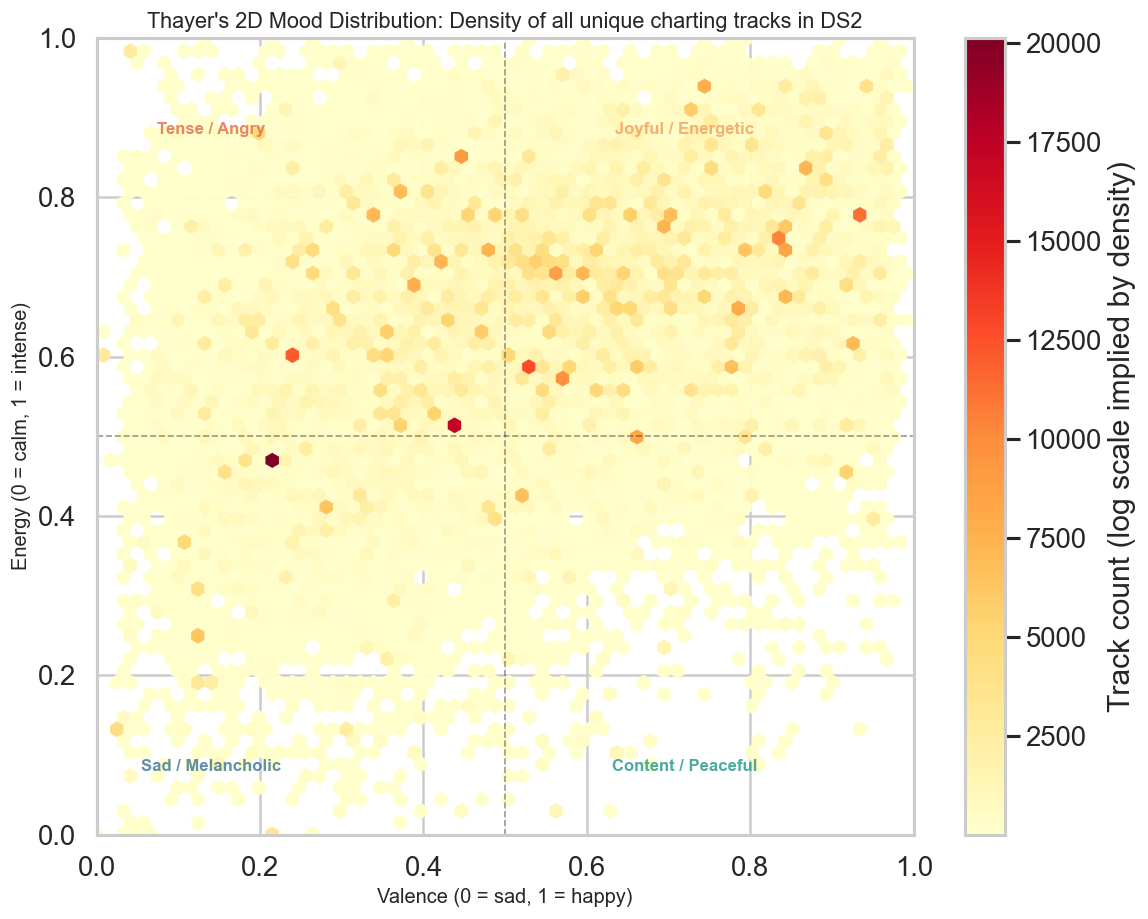

In [62]:
fig, ax = plt.subplots(figsize=(10, 8))

hb = ax.hexbin(
    ds2["valence"], ds2["energy"],
    gridsize=60, cmap="YlOrRd", mincnt=1, linewidths=0.1
)
fig.colorbar(hb, ax=ax, label="Track count (log scale implied by density)")

ax.axvline(V_THRESHOLD, color="#333", linewidth=1, linestyle="--", alpha=0.5)
ax.axhline(E_THRESHOLD, color="#333", linewidth=1, linestyle="--", alpha=0.5)

#Quadrant labels positioned in each corner
label_positions = [
    (0.14, 0.88, "Tense / Angry", MOOD_COLORS["Tense/Angry"]),
    (0.72, 0.88, "Joyful / Energetic", MOOD_COLORS["Joyful/Energetic"]),
    (0.14, 0.08, "Sad / Melancholic", MOOD_COLORS["Sad/Melancholic"]),
    (0.72, 0.08, "Content / Peaceful", MOOD_COLORS["Content/Peaceful"]),
]
for x, y, label, color in label_positions:
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=10, fontweight="bold", color=color, alpha=0.85, ha="center")

ax.set_xlabel("Valence (0 = sad, 1 = happy)", fontsize=12)
ax.set_ylabel("Energy (0 = calm, 1 = intense)", fontsize=12)
ax.set_title(
    f"Thayer's 2D Mood Distribution: Density of all unique charting tracks in DS2",
    fontsize=13
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES / "01_thayer_mood_distribution.png", bbox_inches="tight")
plt.show()

This chart reveals where the majority of the popular music concentrates with "hottest" cells being dark red and red. The spread reveals a higher clustering in the Joyful/Energetic and Tense/Angry quadrants. 

### Geographic Variation
If countries tend to prefer different types of music, then each country should appear in a different area of the mood chart. The chart below shows one point for each country, based on the average happiness level (valence) and average energy level of all the songs that have appeared in its charts.

Each point is coloured by world region. If countries from the same region appear close together, it may suggest that shared regional culture influences music preferences, rather than each country having completely separate tastes.

In [8]:
country_mood = (
    ds2.groupby("country")
    .agg(
        mean_valence=("valence", "mean"),
        mean_energy=("energy", "mean"),
        charting_days=("snapshot_date", "nunique"),
        region=("region", "first")
    )
    .reset_index()
)

print(f"Countries with mood profiles: {len(country_mood)}")
print("Top 10 countries by mean valence (happiest-sounding music):")
display(
    country_mood
    .sort_values("mean_valence", ascending=False)
    .head(10)[["country", "mean_valence", "mean_energy", "region"]]
    .round(3)
    .reset_index(drop=True)
)

Countries with mood profiles: 72
Top 10 countries by mean valence (happiest-sounding music):


,country,mean_valence,mean_energy,region
0,MX,0.674,0.691,Latin America and Caribbean
1,UY,0.659,0.683,Latin America and Caribbean
2,BR,0.653,0.710,Latin America and Caribbean
3,GT,0.637,0.685,Latin America and Caribbean
4,JP,0.637,0.775,East Asia
5,AR,0.634,0.682,Latin America and Caribbean
6,BG,0.633,0.774,Central and Eastern Europe
7,BO,0.621,0.692,Latin America and Caribbean
8,NG,0.621,0.678,Sub-Saharan Africa
9,EG,0.617,0.683,Middle East and North Africa


C:\Users\User\AppData\Local\Temp\ipykernel_25224\3742608293.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for region, group in country_mood.dropna(subset=["region"]).groupby("region"):


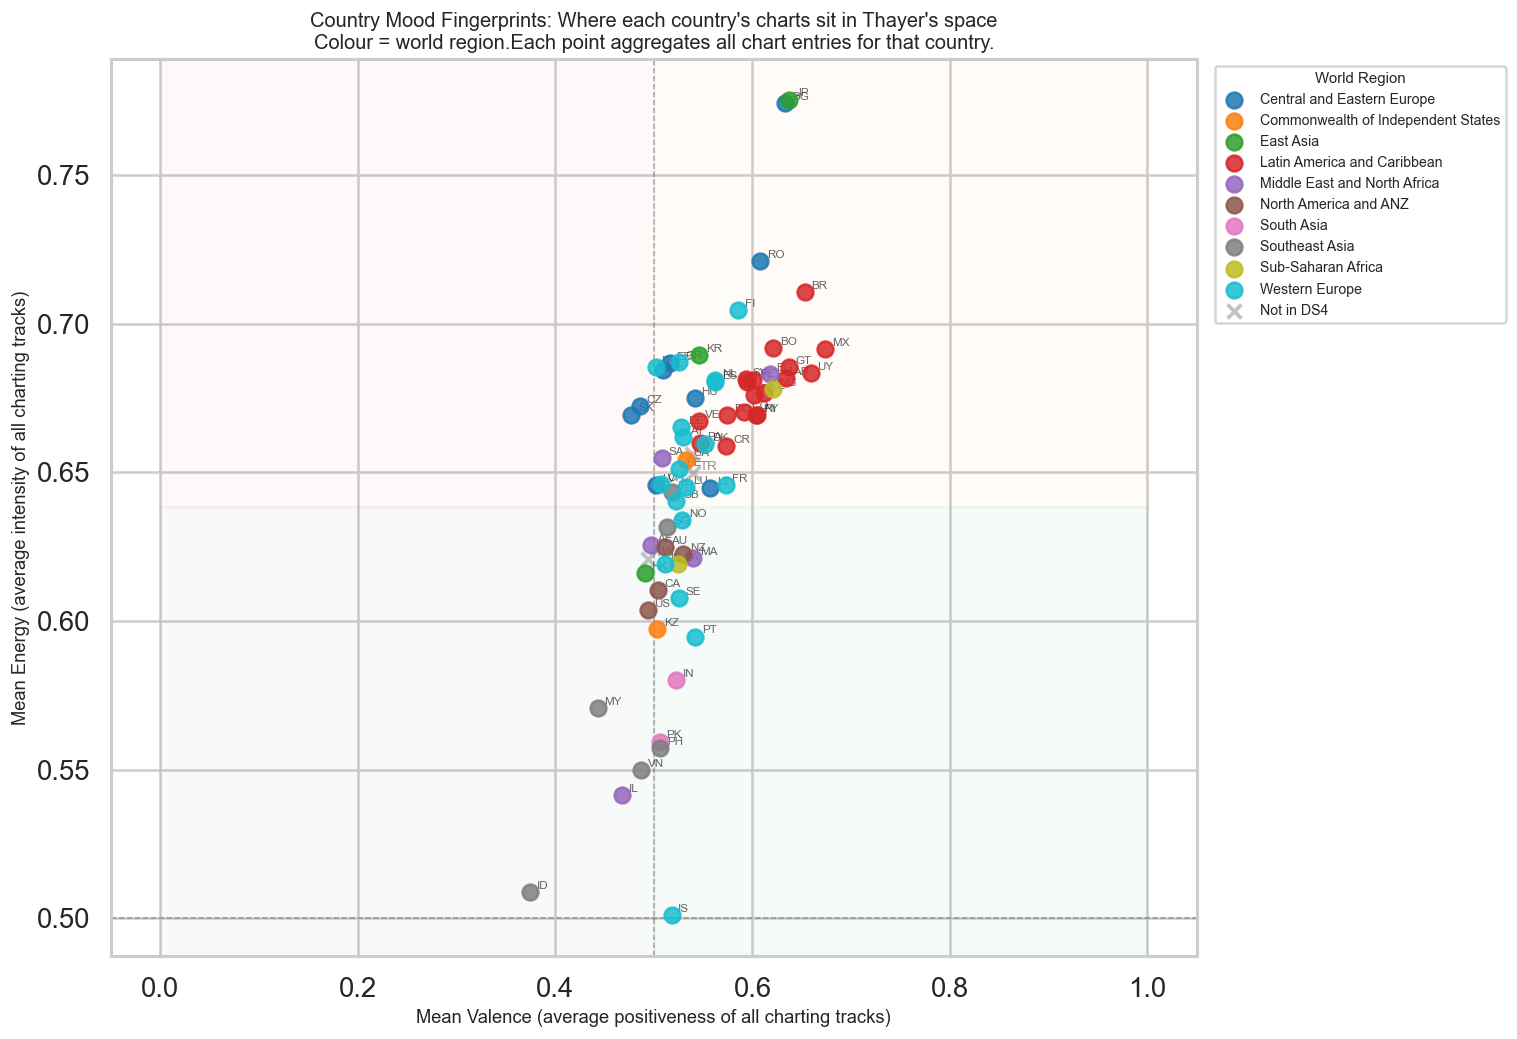

In [18]:
regions = sorted(country_mood["region"].dropna().unique())
region_palette = dict(zip(regions, sns.color_palette("tab10", len(regions))))

fig, ax = plt.subplots(figsize=(13, 9))

ax.axvspan(0, V_THRESHOLD, ymin=E_THRESHOLD, ymax=1, alpha=0.04, color=MOOD_COLORS["Tense/Angry"])
ax.axvspan(V_THRESHOLD, 1, ymin=E_THRESHOLD, ymax=1, alpha=0.04, color=MOOD_COLORS["Joyful/Energetic"])
ax.axvspan(0, V_THRESHOLD, ymin=0, ymax=E_THRESHOLD, alpha=0.04, color=MOOD_COLORS["Sad/Melancholic"])
ax.axvspan(V_THRESHOLD, 1, ymin=0, ymax=E_THRESHOLD, alpha=0.04, color=MOOD_COLORS["Content/Peaceful"])

for region, group in country_mood.dropna(subset=["region"]).groupby("region"):
    color = region_palette[region]
    ax.scatter(group["mean_valence"], group["mean_energy"],
               color=color, s=90, alpha=0.85, label=region, zorder=4)
    for _, row in group.iterrows():
        ax.annotate(
            row["country"],
            (row["mean_valence"], row["mean_energy"]),
            fontsize=7, alpha=0.7, xytext=(4, 2),
            textcoords="offset points"
        )

unmapped = country_mood[country_mood["region"].isna()]
if not unmapped.empty:
    ax.scatter(unmapped["mean_valence"], unmapped["mean_energy"],
               color="#888", s=70, alpha=0.5, marker="x", label="Not in DS4", zorder=3)
    for _, row in unmapped.iterrows():
        ax.annotate(row["country"], (row["mean_valence"], row["mean_energy"]),
                    fontsize=8, alpha=0.5, xytext=(4, 2), textcoords="offset points")

ax.axvline(V_THRESHOLD, color="#555", linewidth=0.9, linestyle="--", alpha=0.5)
ax.axhline(E_THRESHOLD, color="#555", linewidth=0.9, linestyle="--", alpha=0.5)

ax.set_xlabel("Mean Valence (average positiveness of all charting tracks)", fontsize=11)
ax.set_ylabel("Mean Energy (average intensity of all charting tracks)", fontsize=11)
ax.set_title(
    "Country Mood Fingerprints: Where each country's charts sit in Thayer's space\n"
    "Colour = world region.Each point aggregates all chart entries for that country.",
    fontsize=12
)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8.5, title="World Region", title_fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / "02_country_mood_fingerprints.png", bbox_inches="tight")
plt.show()

Although the chart is visually crowded and individual labels are difficult to read, it still reveals a high clustering pattern. Most countries are grouped within a relatively narrow range of valence and energy, suggesting that chart music preferences are broadly similar across countries, with a few noticeable outliers. For that reason, this chart remains useful and will be kept as evidence of overall regional grouping and shared musical mood trends.

### Mood Dimension Distributions by World Region
The fingerprint scatter shows mean positions but hides variance. Violin plots reveal the full distribution shape within each region, showing whether countries in a region are tightly clustered around a shared mood profile or spread across the spectrum.

Using 200,000 randomly sampled rows for violin plots (full dataset: 1,994,031)


C:\Users\User\AppData\Local\Temp\ipykernel_25224\4034365705.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ds2_mapped.groupby("region")["valence"]
C:\Users\User\AppData\Local\Temp\ipykernel_25224\4034365705.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\User\AppData\Local\Temp\ipykernel_25224\4034365705.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\User\AppData\Local\Temp\ipykernel_25224\4034365705.py:31: UserWarning: set_ticklabels() should only be used wi

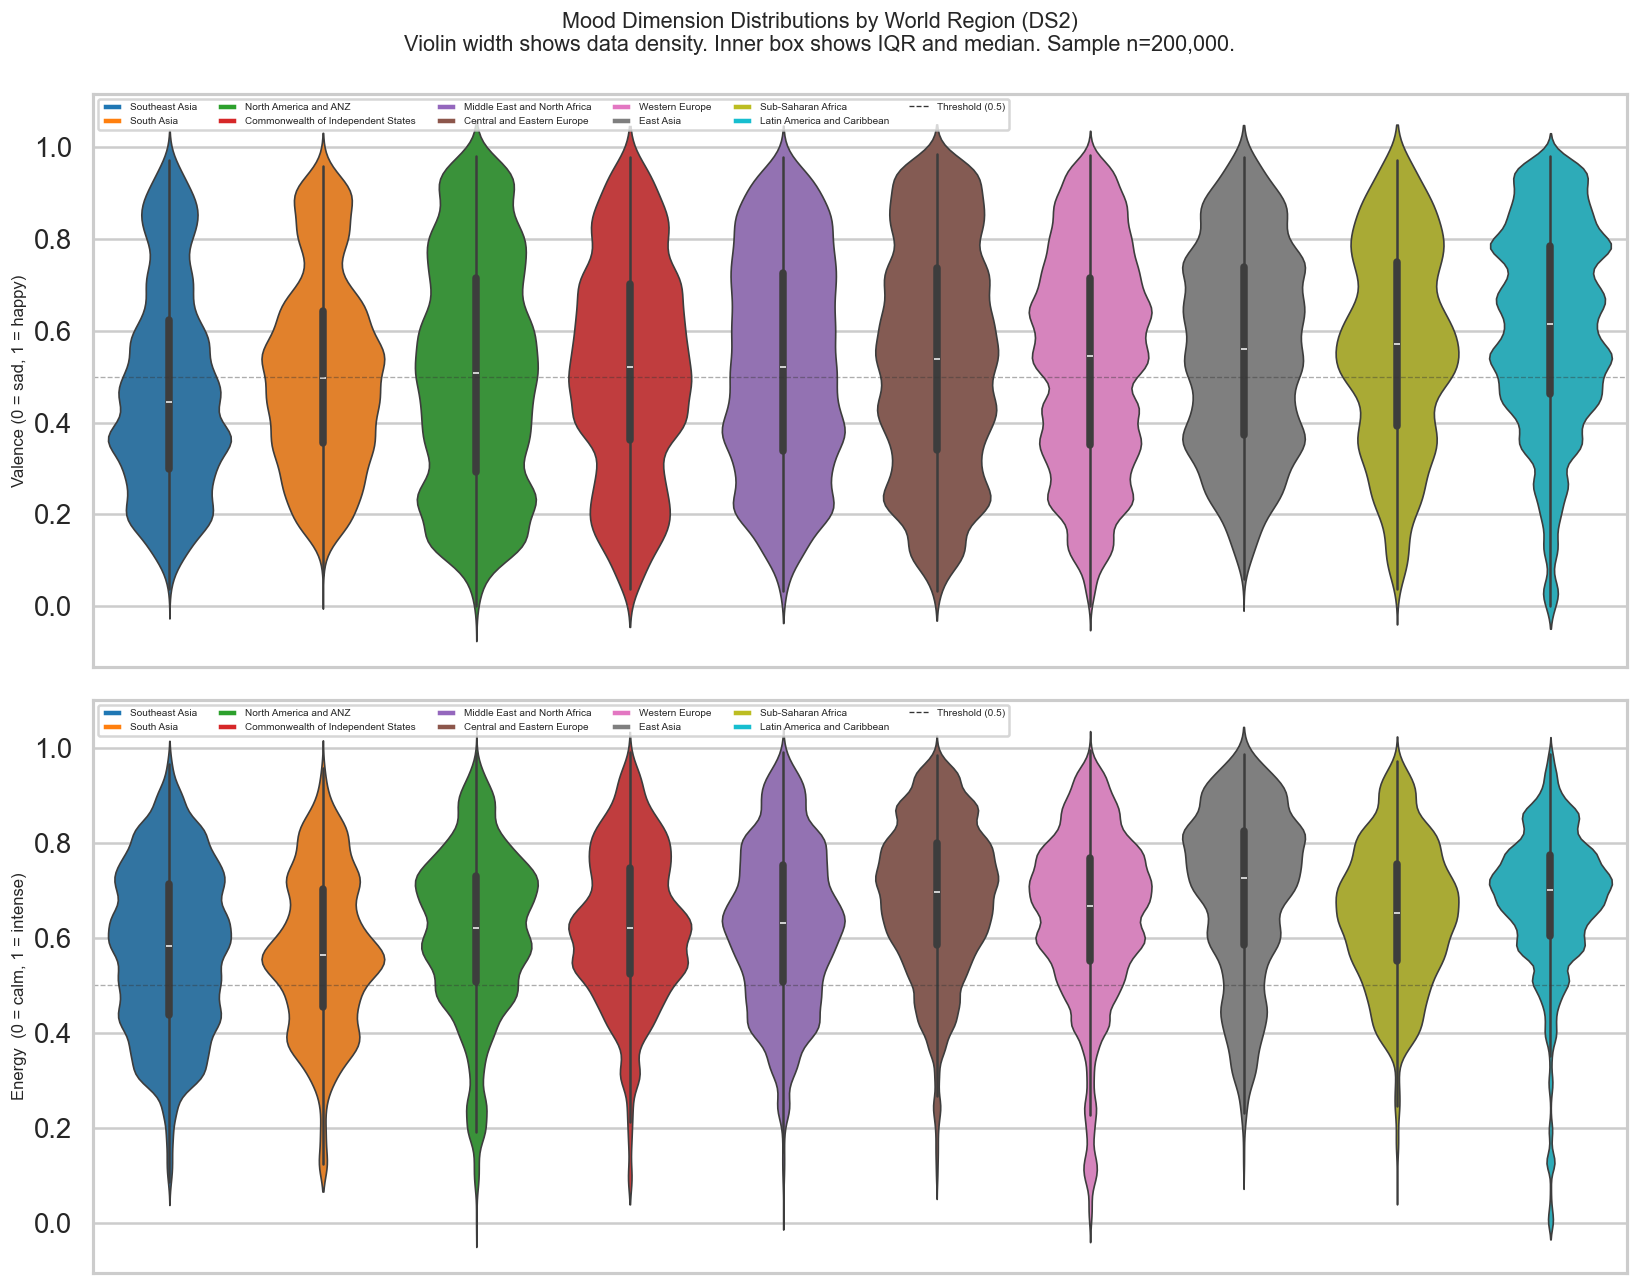

In [28]:
ds2_mapped = ds2[ds2["region"].notna()].copy()

#Using sample for violin plots - 2M points would be slow for KDE estimation
sample_size = 200_000
ds2_sample = ds2_mapped.sample(n=sample_size, random_state=42)
print(f"Using {sample_size:,} randomly sampled rows for violin plots (full dataset: {len(ds2_mapped):,})")

#Sorting regions by median valence so the plot reads left-to-right from saddest to happiest
region_order = (
    ds2_mapped.groupby("region")["valence"]
    .median()
    .sort_values()
    .index.tolist()
)

palette = "tab10"
colors = sns.color_palette(palette, len(region_order))
color_map = dict(zip(region_order, colors))

fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

for ax, feature, label in [
    (axes[0], "valence", "Valence (0 = sad, 1 = happy)"),
    (axes[1], "energy",  "Energy  (0 = calm, 1 = intense)"),
]:
    sns.violinplot(
        data=ds2_sample, x="region", y=feature,
        order=region_order, palette=palette,
        inner="box", linewidth=1, ax=ax
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
    ax.set_ylabel(label, fontsize=10)
    ax.set_xlabel("")
    ax.axhline(0.5, color="#333", linewidth=0.8, linestyle="--", alpha=0.4)
    
    # Build legend with region colors + threshold line
    legend_patches = [mpatches.Patch(facecolor=color_map[region], label=region) 
                      for region in region_order]
    threshold_line = plt.Line2D([0], [0], color="#333", linewidth=0.8, linestyle="--", label="Threshold (0.5)")
    ax.legend(handles=legend_patches + [threshold_line], fontsize=6, loc="upper left", ncol=6)

plt.suptitle(
    "Mood Dimension Distributions by World Region (DS2)\n"
    f"Violin width shows data density. Inner box shows IQR and median. "
    f"Sample n={sample_size:,}.",
    fontsize=13
)
plt.tight_layout()
plt.savefig(FIGURES / "03_mood_by_region_violin.png", bbox_inches="tight")
plt.show()

This plot reveals that energy is near-universally high across all regions charted music worldwide skews intense regardless of cultural context. The more revealing dimension is valence: Latin America, the Caribbean, and Sub-Saharan Africa lean toward happier-sounding music, while the Commonwealth of Independent States and South Asia appear to have a regional preference for more melancholic tones. Crucially, the wide, spread-out violin shapes show that no region is monolithic every region contains multitudes, from deeply sad to more happy tracks coexisting in the same charts.

### Seasonal Patterns
he heatmap below aggregates mean valence for each combination of world region and calendar month. Each cell shows the average positiveness of all tracks charting in that region during that month.

Green cells indicate higher-valence (happier-sounding) music; red cells indicate lower-valence. If seasonal patterns exist, we would expect columns (months) to differ from each other, especially for regions with pronounced seasonal cycles.

C:\Users\User\AppData\Local\Temp\ipykernel_25224\2139932608.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["region", "month"])["valence"]


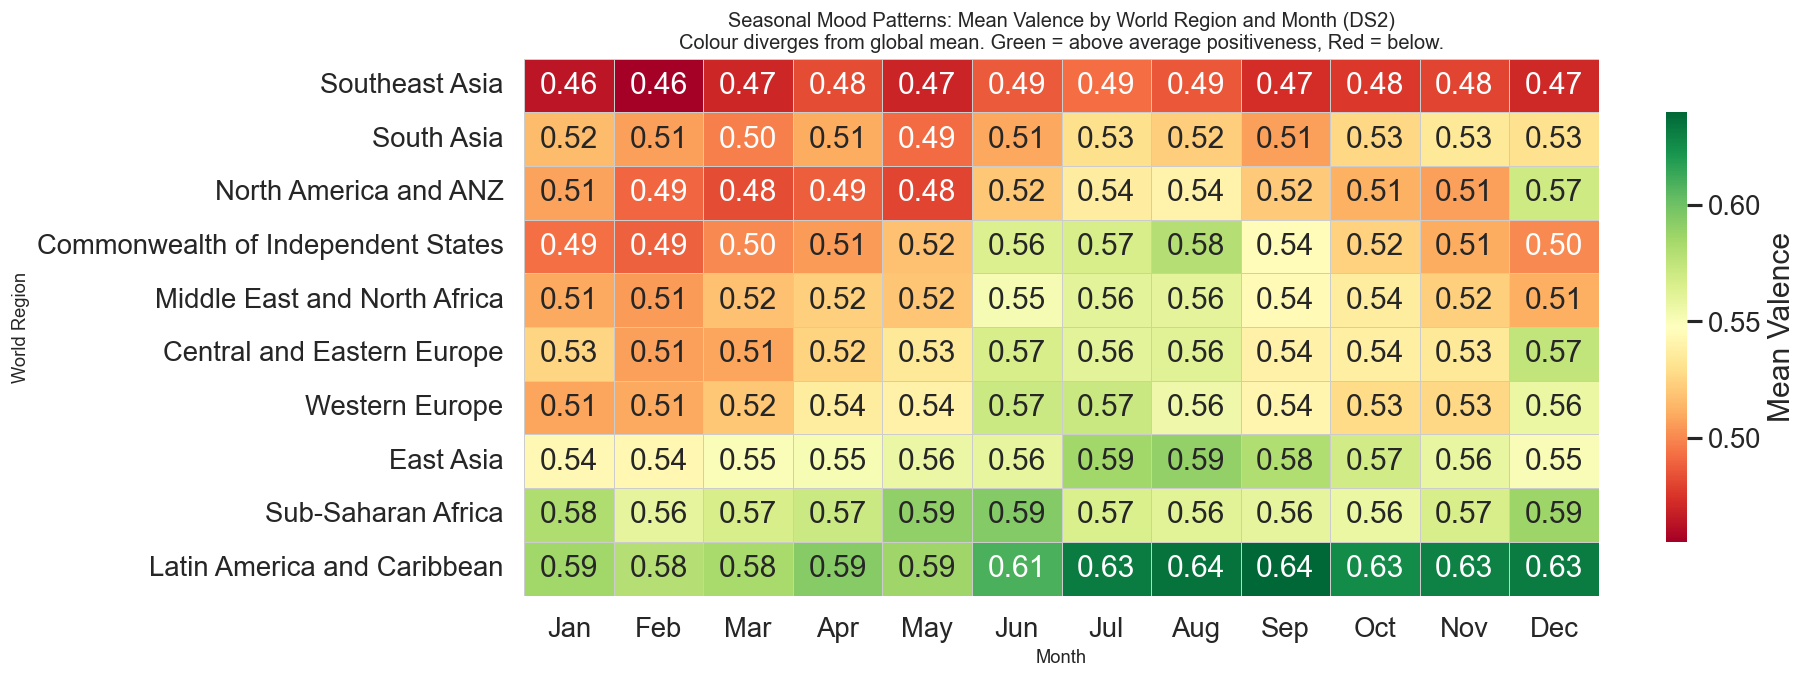

Global mean valence (reference for colour centre): 0.5476


In [30]:
MONTH_NAMES = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

seasonal_pivot = (
    ds2_mapped
    .groupby(["region", "month"])["valence"]
    .mean()
    .unstack("month")
    .rename(columns=MONTH_NAMES)
)

#Sort rows by mean valence (same order as violin plots for consistency)
seasonal_pivot = seasonal_pivot.loc[region_order]

global_mean = ds2_mapped["valence"].mean()

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    seasonal_pivot,
    cmap="RdYlGn",
    center=global_mean,
    vmin=seasonal_pivot.values.min(),
    vmax=seasonal_pivot.values.max(),
    annot=True, fmt=".2f",
    linewidths=0.5, linecolor="#ccc",
    ax=ax,
    cbar_kws={"label": "Mean Valence", "shrink": 0.8}
)
ax.set_title(
    "Seasonal Mood Patterns: Mean Valence by World Region and Month\n"
    "Colour diverges from global mean. Green = above average positiveness, Red = below.",
    fontsize=12
)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("World Region", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / "04_seasonal_mood_heatmap.png", bbox_inches="tight")
plt.show()

print(f"Global mean valence (reference for colour centre): {global_mean:.4f}")

What this heatmap reveals is that valence follows a broadly consistent seasonal pattern across regions, peaking in the summer months (June - August) and dipping in winter, with the Commonwealth of Independent States showing the sharpest swing from 0.49 in winter to 0.58 in summer. Latin America and the Caribbean consistently posts the highest valence scores year-round (0.58–0.64), while Southeast Asia is the only region that never crosses the 0.5 neutral threshold in any month. December brings a notable uptick in North America/ANZ and Central & Eastern Europe, likely driven by the influence of Christmas music on chart composition.

### Audio Feature Relationship
Before using valence and energy as primary mood proxies, it is worth checking how all audio features relate to each other. A high correlation between two features means they carry similar information, therefore using both would be redundant. A low or negative correlation means they add independent signal.

The matrix below shows Pearson correlation coefficients for all nine audio features in DS2. 

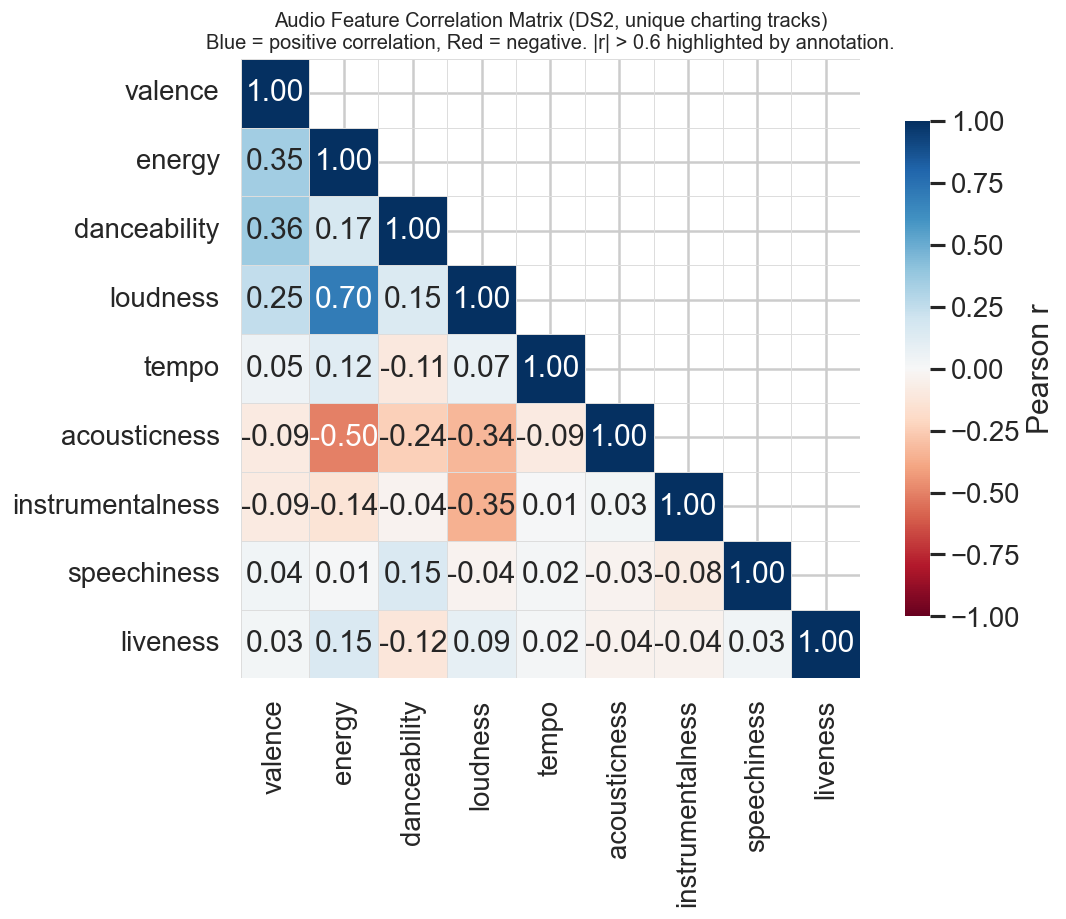

Strongest correlations (|r| > 0.6):


,Feature A,Feature B,r
0,loudness,energy,0.702


In [38]:
AUDIO_FEATURES = [
    "valence", "energy", "danceability", "loudness",
    "tempo", "acousticness", "instrumentalness", "speechiness", "liveness"
]
ds2_unique = ds2.drop_duplicates(subset="spotify_id").copy()
corr = ds2_unique[AUDIO_FEATURES].corr()

#Mask the strictly upper triangle (above diagonal) to avoid redundancy
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt=".2f",
    cmap="RdBu", 
    center=0, 
    vmin=-1, 
    vmax=1,
    square=True, 
    linewidths=0.5, 
    linecolor="#ddd",
    ax=ax,
    cbar_kws={"label": "Pearson r", "shrink": 0.8}
)
ax.set_title(
    "Audio Feature Correlation Matrix (DS2, unique charting tracks)\n"
    "Blue = positive correlation, Red = negative. |r| > 0.6 highlighted by annotation.",
    fontsize=12
)
plt.tight_layout()
plt.savefig(FIGURES / "05_audio_feature_correlation.png", bbox_inches="tight")
plt.show()

#Deeper look into the strongest off-diagonal correlations
corr_long = (
    corr.where(~mask).stack()
    .reset_index()
    .rename(columns={"level_0": "Feature A", "level_1": "Feature B", 0: "r"})
)
corr_long = corr_long[corr_long["Feature A"] != corr_long["Feature B"]]
print("Strongest correlations (|r| > 0.6):")
display(
    corr_long[corr_long["r"].abs() > 0.6]
    .sort_values("r", key=abs, ascending=False)
    .round(3)
    .reset_index(drop=True)
)

What stands out from this matrix is that energy and loudness are the only feature pair with a strong correlation (r = 0.70), meaning they are largely redundant. This is not really surprising as louder tracks could be generally more energetic, so using both in analysis would double-count the same underlying signal. Valence correlates only low/moderate with energy (r = 0.35) and danceability (r = 0.36), confirming that happiness and intensity are somewhat related but genuinely distinct dimensions worth treating separately. Acousticness acts as a broad inverse marker of production intensity, showing meaningful negative correlations with energy (r = - 0.50), loudness (r = - 0.34), and danceability (r = - 0.24). All remaining feature pairs fall well below |r| = 0.3, indicating that tempo, speechiness, instrumentalness, and liveness each contribute largely independent information - the feature space is not heavily collinear, which validates using multiple features together without significant redundancy concerns.

### National Wellbeing Probe
While Experiment 2 will formally test whether a country's happiness score (from the World Happiness Report 2024) predicts the emotional tone of its charting music. Before running any statistical test, it is useful to visualise the relationship.

The bubble chart below plots each country at the intersection of its happiness ladder score (x-axis) and its mean music valence (y-axis). **Bubble size encodes data confidence:** larger bubbles represent countries with more charting days in DS2, meaning their mood average is based on more observations.

A dashed trend line and the Pearson correlation coefficient are shown as a preliminary signal. Whether this correlation is statistically meaningful is the question for Experiment 2.

In [39]:
happiness_data = (
    country_mood
    .merge(
        ds4[["country_code", "Ladder score"]].dropna(subset=["country_code"]),
        left_on="country", right_on="country_code",
        how="inner"
    )
    .drop(columns=["country_code"])
)

print(f"Countries with both mood profile and happiness score: {len(happiness_data)}")
display(
    happiness_data
    .sort_values("Ladder score", ascending=False)
    [["country", "Ladder score", "mean_valence", "mean_energy", "charting_days", "region"]]
    .head(10)
    .round(3)
    .reset_index(drop=True)
)

Countries with both mood profile and happiness score: 69


,country,Ladder score,mean_valence,mean_energy,charting_days,region
0,FI,7.741,0.585,0.705,583,Western Europe
1,DK,7.583,0.552,0.660,579,Western Europe
2,IS,7.525,0.518,0.501,578,Western Europe
3,SE,7.344,0.525,0.608,580,Western Europe
4,IL,7.341,0.468,0.541,582,Middle East and North Africa
5,NL,7.319,0.562,0.681,578,Western Europe
6,NO,7.302,0.529,0.634,579,Western Europe
7,LU,7.122,0.533,0.645,578,Western Europe
8,CH,7.060,0.507,0.646,579,Western Europe
9,AU,7.057,0.511,0.625,579,North America and ANZ


C:\Users\User\AppData\Local\Temp\ipykernel_25224\2761058964.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for region, group in happiness_data.dropna(subset=["region"]).groupby("region"):


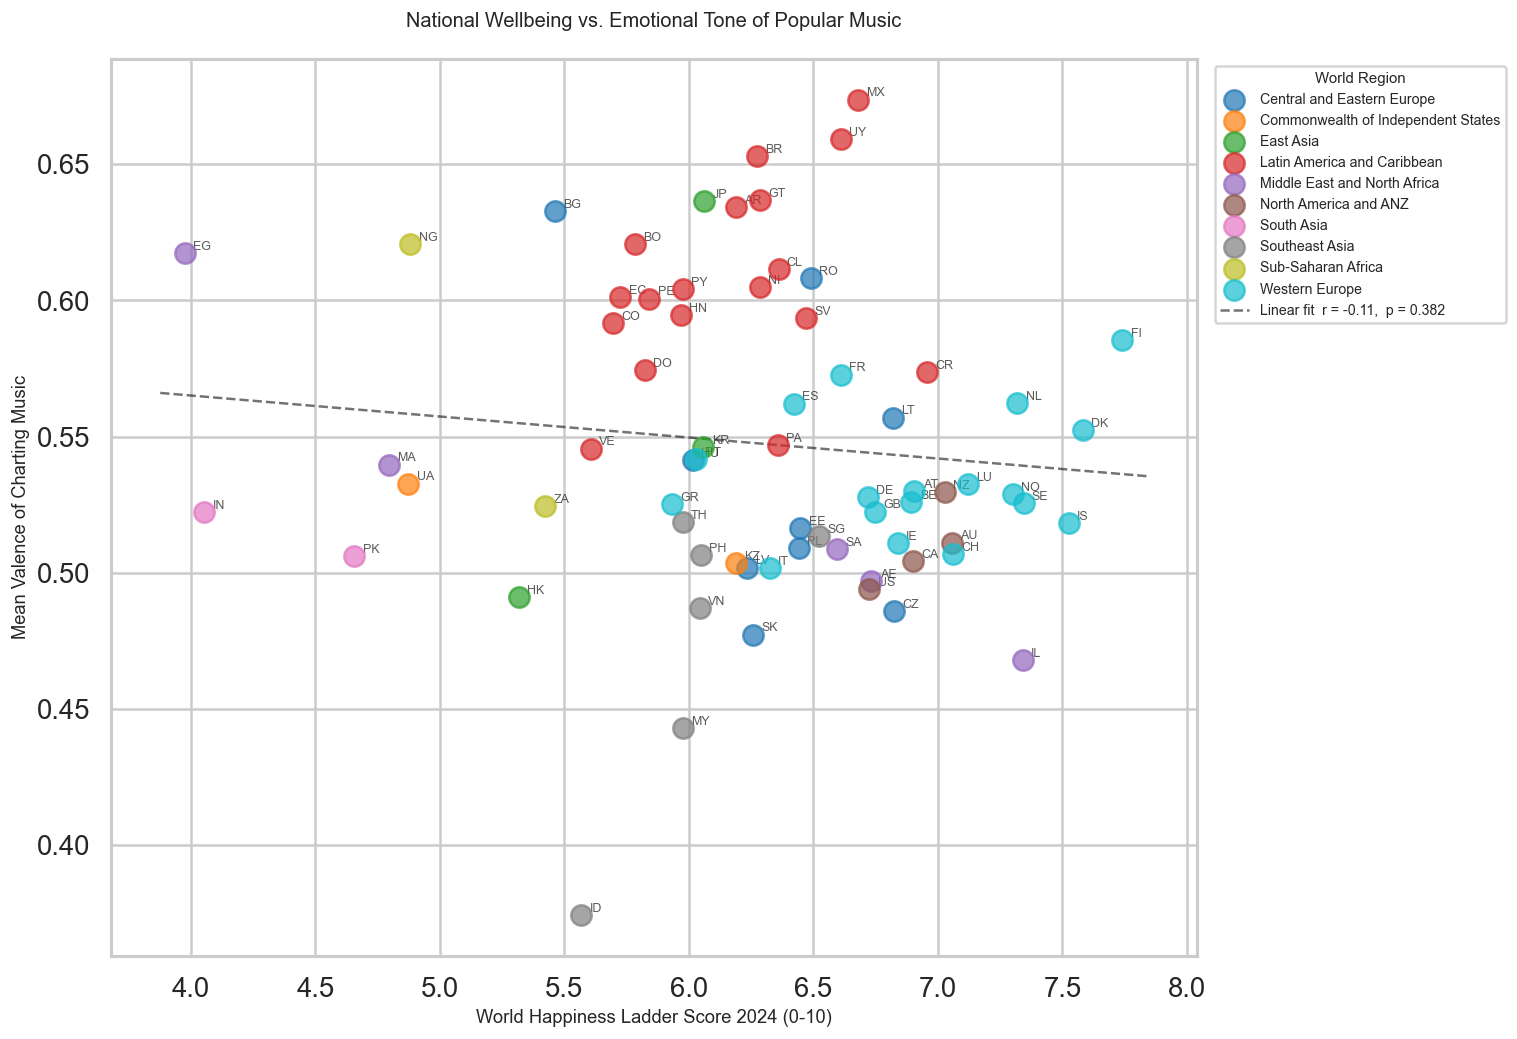

Preliminary Pearson r = -0.107, p = 0.3819
Charting days per country: min=418, max=583
Experiment 2 will test this formally with Spearman rank correlation and control variables.


In [57]:
valid_mask = happiness_data["Ladder score"].notna() & happiness_data["mean_valence"].notna()
slope, intercept, r_val, p_val, _ = stats.linregress(
    happiness_data.loc[valid_mask, "Ladder score"],
    happiness_data.loc[valid_mask, "mean_valence"]
)

regions_h = sorted(happiness_data["region"].dropna().unique())
palette_h = dict(zip(regions_h, sns.color_palette("tab10", len(regions_h))))

fig, ax = plt.subplots(figsize=(13, 9))

for region, group in happiness_data.dropna(subset=["region"]).groupby("region"):
    ax.scatter(
        group["Ladder score"], group["mean_valence"],
        s=150, color=palette_h[region], alpha=0.7,
        label=region, zorder=4
    )
    for _, row in group.iterrows():
        ax.annotate(
            row["country"],
            (row["Ladder score"], row["mean_valence"]),
            fontsize=7.5, alpha=0.75, xytext=(5, 2),
            textcoords="offset points"
        )

# Trend line
x_range = np.linspace(
    happiness_data["Ladder score"].min() - 0.1,
    happiness_data["Ladder score"].max() + 0.1,
    200
)
ax.plot(
    x_range, slope * x_range + intercept,
    color="black", linewidth=1.5, linestyle="--", alpha=0.55,
    label=f"Linear fit  r = {r_val:.2f},  p = {p_val:.3f}"
)

ax.set_xlabel("World Happiness Ladder Score 2024 (0-10)", fontsize=11)
ax.set_ylabel("Mean Valence of Charting Music", fontsize=11)
ax.set_title(
    "National Wellbeing vs. Emotional Tone of Popular Music\n",
    fontsize=12
)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8.5,
          title="World Region", title_fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / "06_happiness_vs_valence_bubble.png", bbox_inches="tight")
plt.show()

print(f"Preliminary Pearson r = {r_val:.3f}, p = {p_val:.4f}")
print(f"Charting days per country: min={happiness_data['charting_days'].min()}, max={happiness_data['charting_days'].max()}")
print("Experiment 2 will test this formally with Spearman rank correlation and control variables.")

The scatter is wide at every happiness level, with countries spanning nearly the full valence range (0.37 - 0.68) regardless of where they sit on the happiness axis. Latin American countries cluster visibly high on valence despite only moderate happiness scores (5.5 - 6.5), while Western European countries which represent some of the largest and most data-confident bubbles sit at high happiness scores but only mid-range valence, the two patterns together actively pulling the correlation toward zero. The Pearson correlation between the two variables is r = - 0.11 (p = 0.382), suggests that national happiness does not predict the emotional tone of a country's popular music in any meaningful linear way.

### Individual Mental Health Profiles Probe

DS3 operates at the individual level: 736 survey respondents, each with self-reported mental health scores and genre listening frequencies. Two visualisations will help to set up Experiment 3:

1. **KDE and box plots** which will show the shape of each mental health score distribution - where scores cluster, how wide the spread is, and whether the distributions look similar or distinct across conditions.
2. **Genre - mental health heatmap** previews whether genre preference appears to differ between respondents with high vs. low scores on each condition.

C:\Users\User\AppData\Local\Temp\ipykernel_25224\249114283.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


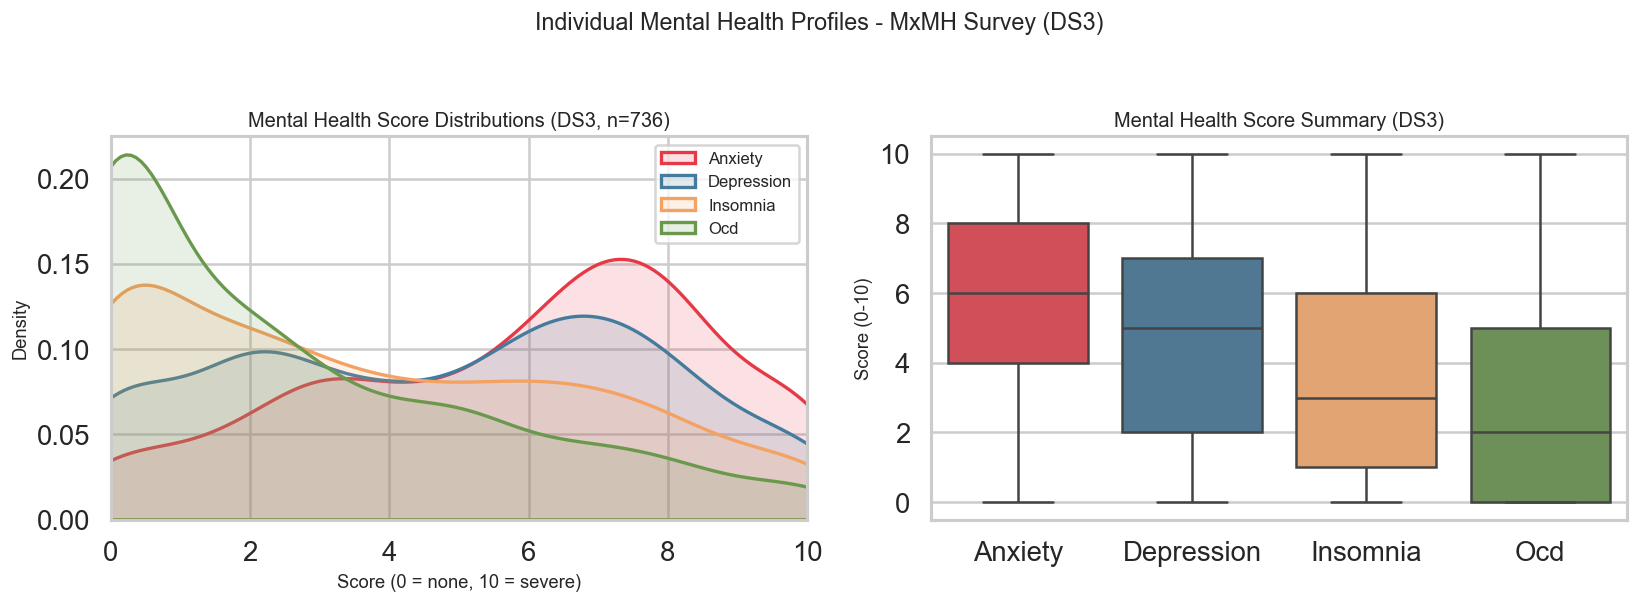

Mental health score summary statistics:


,anxiety,depression,insomnia,ocd
count,736.00,736.00,736.00,736.00
mean,5.84,4.80,3.74,2.64
std,2.79,3.03,3.09,2.84
min,0.00,0.00,0.00,0.00
25%,4.00,2.00,1.00,0.00
50%,6.00,5.00,3.00,2.00
75%,8.00,7.00,6.00,5.00
max,10.00,10.00,10.00,10.00


In [58]:
MH_COLS = ["anxiety", "depression", "insomnia", "ocd"]
MH_COLORS = {
    "anxiety": "#E63946",
    "depression": "#457B9D",
    "insomnia": "#F4A261",
    "ocd": "#6A994E",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Left: overlaid KDE curves show distributional shape
for col in MH_COLS:
    sns.kdeplot(
        ds3[col], ax=axes[0],
        label=col.capitalize(),
        color=MH_COLORS[col],
        fill=True, alpha=0.15, linewidth=2
    )
axes[0].set_xlabel("Score (0 = none, 10 = severe)", fontsize=11)
axes[0].set_ylabel("Density", fontsize=11)
axes[0].set_title("Mental Health Score Distributions (DS3, n=736)", fontsize=12)
axes[0].set_xlim(0, 10)
axes[0].legend(fontsize=10)

# Right: box plots for median and IQR comparison
mh_long = (
    ds3[MH_COLS]
    .rename(columns={c: c.capitalize() for c in MH_COLS})
    .melt(var_name="Condition", value_name="Score")
)
sns.boxplot(
    data=mh_long, x="Condition", y="Score", ax=axes[1],
    palette=[MH_COLORS[c] for c in MH_COLS],
    linewidth=1.5
)
axes[1].set_title("Mental Health Score Summary (DS3)", fontsize=12)
axes[1].set_xlabel("")
axes[1].set_ylabel("Score (0-10)", fontsize=11)

plt.suptitle(
    "Individual Mental Health Profiles - MxMH Survey (DS3)",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.savefig(FIGURES / "07_mental_health_distributions.png", bbox_inches="tight")
plt.show()

print("Mental health score summary statistics:")
display(ds3[MH_COLS].describe().round(2))

Looking at the charts Anxiety stands out as the most severe and distinctively shaped condition in this sample its KDE is bimodal with a clear peak around 7–8, and its box plot shows a median of approximately 6 with an IQR spanning roughly 4-8, meaning the typical respondent reports moderately high anxiety. Insomnia and OCD both peak sharply near zero and tail off gradually, indicating that most respondents report low-to-absent symptoms, though the full 0-10 range is represented in both. Depression sits between these extremes right-skewed with a median around 3 and most mass below 5, but with a long tail reaching severe levels.

Anxiety: median = 6 | Low group: 375 | High group: 361
Depression: median = 5 | Low group: 392 | High group: 344
Insomnia: median = 3 | Low group: 387 | High group: 349
Ocd: median = 2 | Low group: 439 | High group: 297


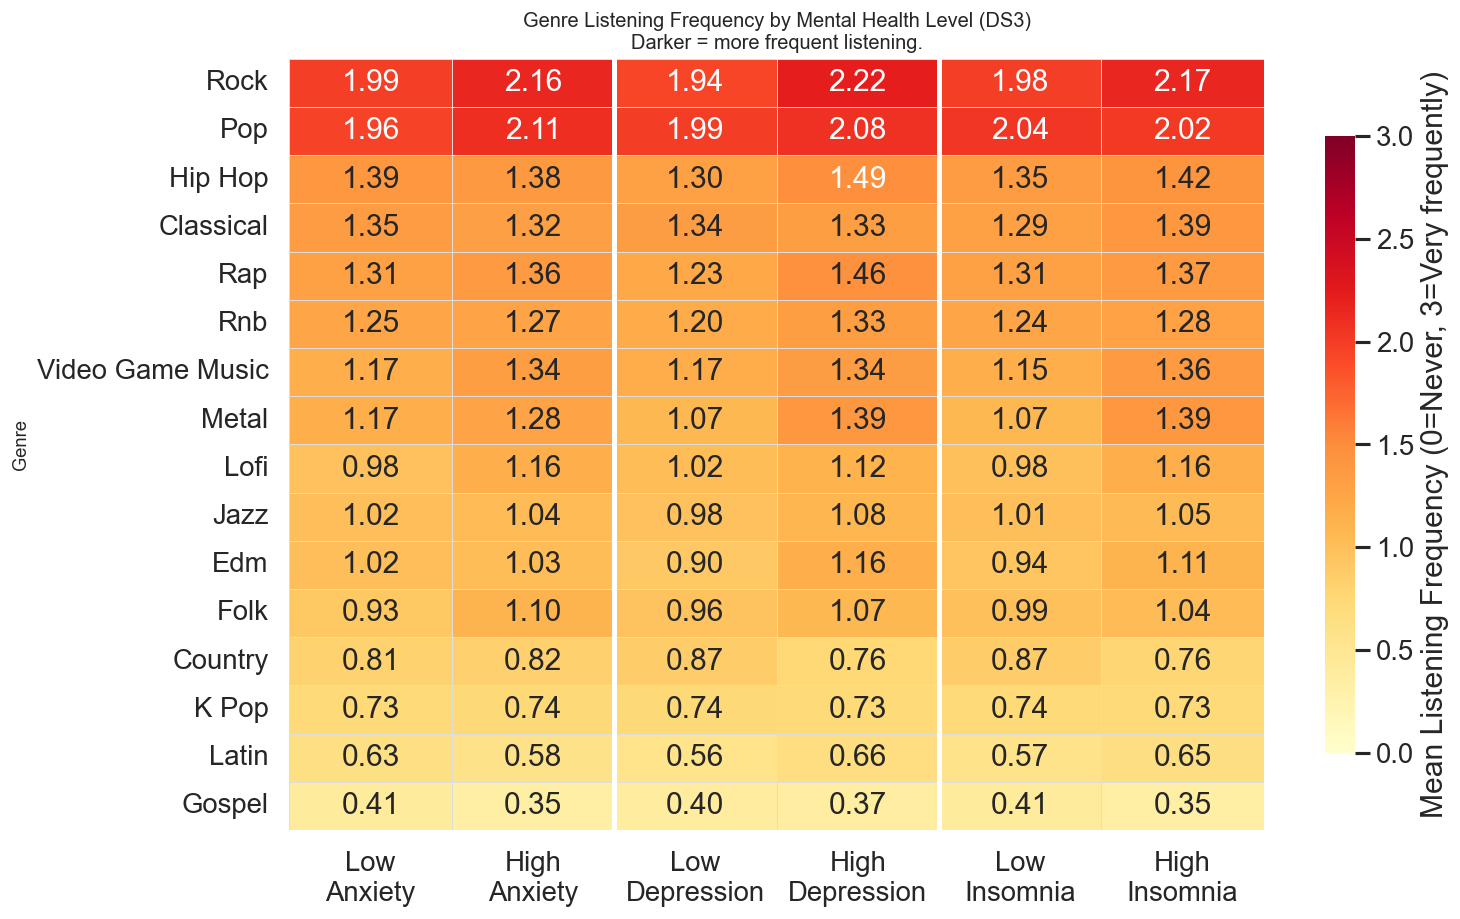

In [61]:
FREQ_COLS = [c for c in ds3.columns if c.startswith("freq_")]
FREQ_ORDER = {"Never": 0, "Rarely": 1, "Sometimes": 2, "Very frequently": 3}

#Encoding frequency strings to ordinal integers for this visualisation (this is a heatmap this is why it needs the encoding)
ds3_enc = ds3.copy()
for col in FREQ_COLS:
    ds3_enc[col] = ds3_enc[col].map(FREQ_ORDER)

#Split each respondent into High/Low group using the median as the cut-point (to gain rough picture)
for mh in MH_COLS:
    cut = ds3_enc[mh].median()
    ds3_enc[f"{mh}_group"] = ds3_enc[mh].apply(lambda x: "High" if x > cut else "Low")
    print(f"{mh.capitalize()}: median = {cut:.0f} | Low group: {(ds3_enc[mh + '_group'] == 'Low').sum()} | High group: {(ds3_enc[mh + '_group'] == 'High').sum()}")

genre_labels = {
    col: col.replace("freq_", "").replace("_", " ").title()
    for col in FREQ_COLS
}

heatmap_cols = {}
for mh in ["anxiety", "depression", "insomnia"]:  # OCD excluded for space
    for level in ["Low", "High"]:
        col_label = f"{level}\n{mh.capitalize()}"
        group_rows = ds3_enc[ds3_enc[f"{mh}_group"] == level]
        heatmap_cols[col_label] = {
            genre_labels[c]: group_rows[c].mean()
            for c in FREQ_COLS
        }

heatmap_df = pd.DataFrame(heatmap_cols)

#Sort genres by overall mean frequency
genre_order = ds3_enc[FREQ_COLS].mean().rename(genre_labels).sort_values(ascending=False).index
heatmap_df = heatmap_df.loc[genre_order]

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(
    heatmap_df,
    cmap="YlOrRd",
    annot=True, fmt=".2f",
    linewidths=0.5, linecolor="#ddd",
    ax=ax,
    cbar_kws={"label": "Mean Listening Frequency (0=Never, 3=Very frequently)", "shrink": 0.8},
    vmin=0, vmax=3
)

for x in [2, 4]:
    ax.axvline(x, color="white", linewidth=3)

ax.set_title(
    "Genre Listening Frequency by Mental Health Level (DS3)\n"
    "Darker = more frequent listening.",
    fontsize=12
)
ax.set_xlabel("", fontsize=11)
ax.set_ylabel("Genre", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / "08_genre_mental_health_heatmap.png", bbox_inches="tight")
plt.show()

This heatmap shows that Rock and Pop dominate uniformly they are the most listened-to genres across every mental health group by a niticeable margin, with no meaningful difference between high and low scorers on any condition. The high-depression and high-insomnia columns consistently show slightly elevated listening frequencies across most genres compared to their low counterparts, suggesting that higher symptom severity correlates weakly with more frequent music engagement overall rather than genre-specific preferences. Gospel and Latin sit at the floor across all groups (0.35 – 0.66), also showing negligible variation. Notably, K-Pop is remarkably flat across all six columns (0.73 – 0.74), making it the genre least associated with any mental health differentiation in this dataset.

### EDA Summary

The visualisations in this notebook reveal both strong and weak signals before formal testing:

**1. Geographic and seasonal signal exists but primarily in valence, not energy.**
Energy is near-universally high across all regions and time periods, indicating that charting music worldwide prioritizes intensity regardless of geography or season. The meaningful geographic differentiation emerges in valence: Latin America, the Caribbean, and Sub-Saharan Africa consistently chart happier-sounding music (0.58 - 0.64), while the Commonwealth of Independent States and South Asia favor melancholic tones (0.49 - 0.53). Seasonal patterns in valence are consistent across regions, peaking in summer (June - August) and dipping in winter, with December showing a notable uplift in North America/ANZ and Central & Eastern Europe, likely driven by Christmas music. Critically, no region is monolithic, every region shows wide internal variance, indicating coexistence of diverse moods within a single regional chart. This validates Experiment 1's investigation of geographic and temporal mood patterns.

**2. National happiness does NOT predict music valence.**
The preliminary Pearson correlation between national happiness and mean music valence is r = -0.11 (p = 0.382) which is very small. The scatter across happiness levels is too wide: countries at every happiness level span nearly the full valence range (0.37 - 0.68), with Latin American countries charting high valence despite moderate happiness scores, while Western European countries at high happiness sit at only mid-range valence. These countervailing patterns actively pull the correlation toward null. Experiment 2 will test whether alternative methods (Spearman rank, regional controls... etc.) reveal any latent structure, but the EDA provides no strong visual signal that happiness predicts charting mood.

**3. Genre preferences show no meaningful differentiation by mental health level.**
Rock and Pop dominate uniformly across all mental health groups, with no distinguishable pattern between high and low scorers on any condition. The heatmap shows a weak overall trend: respondents with higher mental health symptom scores engage more frequently with music across all genres, but this reflects increased engagement generally, not genre specific preference shifts. K-Pop is remarkably flat across all groups (0.73 - 0.74), making it the least mental-health-differentiated genre in the dataset. Gospel and Latin sit at the floor across all groups with no variation. Experiment 3 will apply chi-squared testing to formally assess whether the small observed differences exceed random noise, but the EDA suggests genre preference is independent of mental health state.

**Key analytical decisions carried forward to notebook 04:**
- The Thayer threshold (`V_THRESHOLD = 0.5`, `E_THRESHOLD = 0.5`) is parameterised and will be varied in the calibration section of Experiment 1 to test sensitivity.
- The median split used in the genre heatmap above is one choice; Experiment 3 will vary this threshold and report how chi-squared results change.
- Feature selection (valence as primary, energy as secondary) is supported by the correlation matrix: energy and loudness are redundant (r = 0.70), while valence correlates only low/moderately with both (r ≈ 0.35), confirming they measure partially independent dimensions.
- The absence of signal in the EDA does not invalidate the experiments it simply means the hypotheses may not survive formal testing which is perfectly accetable result for this project.